Multi-grid SINDy

In [5]:
!pip install pysindy scikit-learn scipy matplotlib pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.4/123.4 kB 2.7 MB/s eta 0:00:00


In [1]:
from google.colab import files
uploaded = files.upload()

Saving era5_nyc_summer_accum.csv to era5_nyc_summer_accum.csv


Forward Simulation of Degree-2 SINDy with coeeficients below:

$ Tpred(t+1)=Tpred(t) +  Δt⋅(-0.087​T+0.153​R+ -0.033​W + -0.023 RT) $

In [18]:
import pandas as pd
import numpy as np
from scipy.signal import savgol_filter
from sklearn.preprocessing import StandardScaler
import pysindy as ps

# =========================
# Load data
# =========================
df = pd.read_csv('/content/era5_nyc_summer_accum.csv')
df['valid_time'] = pd.to_datetime(df['valid_time'])

# =========================
# Get unique grid points
# =========================
grid_points = df[['latitude', 'longitude']].drop_duplicates()

print("Total grid points:", len(grid_points))

# =========================
# SINDy settings
# =========================
dt = 1  # hours

poly_lib = ps.PolynomialLibrary(
    degree=1,
    include_interaction=True,
    include_bias=False
)

threshold = 0.01   # start here because 0.05 removed all coefficients

results = []
models = {}

# =========================
# Train one SINDy model per grid
# =========================
for i, row in grid_points.iterrows():

    lat = row['latitude']
    lon = row['longitude']

    df_g = df[
        (df['latitude'] == lat) &
        (df['longitude'] == lon)
    ].sort_values('valid_time')

    if len(df_g) < 50:
        continue

    # =========================
    # Variables
    # =========================
    T = df_g['temp_C'].values
    R = df_g['ssrd'].values
    W = df_g['wind_speed'].values

    # =========================
    # Smooth temperature
    # =========================
    T_smooth = savgol_filter(
        T,
        window_length=11,
        polyorder=3
    )

    # =========================
    # Build dataset
    # =========================
    X = T_smooth.reshape(-1, 1)
    U = np.column_stack([R, W])

    # =========================
    # Scale per grid
    # =========================
    scaler_X = StandardScaler()
    scaler_U = StandardScaler()

    X_scaled = scaler_X.fit_transform(X)
    U_scaled = scaler_U.fit_transform(U)

    # =========================
    # Fit SINDy model
    # =========================
    model = ps.SINDy(
    optimizer=ps.STLSQ(threshold=threshold),
    feature_library=poly_lib
)

    model.fit(
        X_scaled,
        u=U_scaled,
        t=dt
    )

    coef = model.coefficients().flatten()
    feature_names = model.get_feature_names()

    # =========================
    # Store model and scalers
    # =========================
    models[(lat, lon)] = {
        "model": model,
        "scaler_X": scaler_X,
        "scaler_U": scaler_U,
        "feature_names": feature_names
    }

    # =========================
    # Store coefficients
    # =========================
    result = {
        "lat": lat,
        "lon": lon,
        "n_samples": len(df_g),
        "threshold": threshold
    }

    for name, value in zip(feature_names, coef):
        result[name] = value

    results.append(result)

# =========================
# Convert results to dataframe
# =========================
results_df = pd.DataFrame(results)

print("\nFinished training per-grid SINDy models.")
print("Successful grids:", len(results_df))

print("\nFeature names:")
print(feature_names)

print("\nResults preview:")
print(results_df.head())

# =========================
# Save coefficients
# =========================
results_df.to_csv("sindy_degree2_per_grid_results.csv", index=False)

print("\nSaved as: sindy_degree2_per_grid_results.csv")

Total grid points: 45

Finished training per-grid SINDy models.
Successful grids: 45

Feature names:
['x0', 'u0', 'u1']

Results preview:
    lat    lon  n_samples  threshold        x0        u0        u1
0  41.0 -75.00       2208       0.01 -0.083136  0.138475 -0.031743
1  41.0 -74.75       2208       0.01 -0.082062  0.135301 -0.032613
2  41.0 -74.50       2208       0.01 -0.081604  0.133179 -0.034153
3  41.0 -74.25       2208       0.01 -0.080488  0.130874 -0.034846
4  41.0 -74.00       2208       0.01 -0.070361  0.120790 -0.034540

Saved as: sindy_degree2_per_grid_results.csv


## Temporal Reconstruction

You compute:

Start from real initial value:

$ Tpred(t+1)=Tpred(t) +  Δt⋅(a1​T+a2​R+a3​W) $

Then step forward iteratively

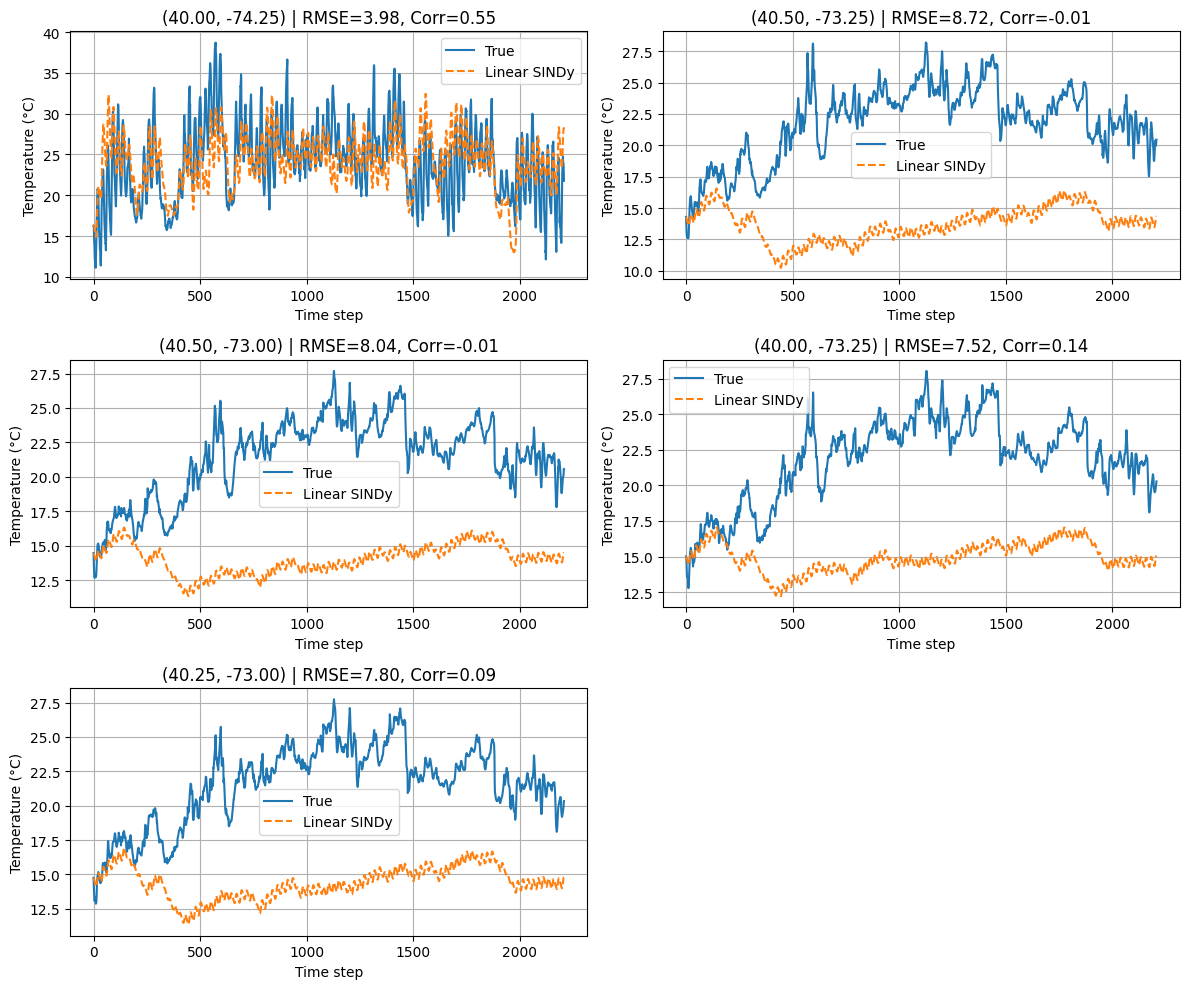

     lat    lon    T_coef    R_coef    W_coef      rmse      corr
0  40.00 -74.25 -0.062055  0.105088 -0.039346  3.984190  0.546344
1  40.50 -73.25  0.000000  0.024959  0.000000  8.715038 -0.013636
2  40.50 -73.00  0.000000  0.021120  0.000000  8.038155 -0.012265
3  40.00 -73.25  0.000000  0.020912  0.000000  7.516265  0.137141
4  40.25 -73.00  0.000000  0.023694  0.000000  7.795052  0.090586

Mean RMSE: 7.209740031884403
Mean Corr: 0.149634018482403


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# =========================
# Select 5 unique grid points
# =========================
sample_grids = results_df[['lat', 'lon']].drop_duplicates().sample(
    n=5,
    random_state=42
)

plt.figure(figsize=(12, 10))
rollout_results = []

# =========================
# Forward simulation using linear SINDy coefficients
# dx/dt = aT*x + aR*u0 + aW*u1
# =========================
for i, (_, row) in enumerate(sample_grids.iterrows()):

    lat = row['lat']
    lon = row['lon']

    df_g = df[
        (df['latitude'] == lat) &
        (df['longitude'] == lon)
    ].sort_values('valid_time')

    T = df_g['temp_C'].values
    R = df_g['ssrd'].values
    W = df_g['wind_speed'].values

    # =========================
    # Scale per grid
    # =========================
    scaler_X = StandardScaler()
    scaler_U = StandardScaler()

    T_scaled = scaler_X.fit_transform(T.reshape(-1, 1)).flatten()
    U_scaled = scaler_U.fit_transform(np.column_stack([R, W]))

    R_scaled = U_scaled[:, 0]
    W_scaled = U_scaled[:, 1]

    # =========================
    # Get linear SINDy coefficients
    # Use whichever column names exist in your results_df
    # =========================
    if 'T_coef' in results_df.columns:
        coef_row = results_df[
            (results_df['lat'] == lat) &
            (results_df['lon'] == lon)
        ].iloc[0]

        aT = coef_row['T_coef']
        aR = coef_row['R_coef']
        aW = coef_row['W_coef']

    else:
        coef_row = results_df[
            (results_df['lat'] == lat) &
            (results_df['lon'] == lon)
        ].iloc[0]

        aT = coef_row['x0']
        aR = coef_row['u0']
        aW = coef_row['u1']

    # =========================
    # Manual rollout
    # =========================
    dt = 1

    T_pred_scaled = np.zeros_like(T_scaled)
    T_pred_scaled[0] = T_scaled[0]

    for t in range(len(T_scaled) - 1):
        dTdt = (
            aT * T_pred_scaled[t]
            + aR * R_scaled[t]
            + aW * W_scaled[t]
        )

        T_pred_scaled[t + 1] = T_pred_scaled[t] + dt * dTdt

    # =========================
    # Convert back to Celsius
    # =========================
    T_pred = scaler_X.inverse_transform(
        T_pred_scaled.reshape(-1, 1)
    ).flatten()

    # =========================
    # Metrics
    # =========================
    rmse = np.sqrt(mean_squared_error(T, T_pred))
    corr = np.corrcoef(T, T_pred)[0, 1]

    rollout_results.append({
        "lat": lat,
        "lon": lon,
        "T_coef": aT,
        "R_coef": aR,
        "W_coef": aW,
        "rmse": rmse,
        "corr": corr
    })

    # =========================
    # Plot
    # =========================
    plt.subplot(3, 2, i + 1)
    plt.plot(T, label="True")
    plt.plot(T_pred, "--", label="Linear SINDy")
    plt.title(f"({lat:.2f}, {lon:.2f}) | RMSE={rmse:.2f}, Corr={corr:.2f}")
    plt.xlabel("Time step")
    plt.ylabel("Temperature (°C)")
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

# =========================
# Results dataframe
# =========================
rollout_results_df = pd.DataFrame(rollout_results)

print(rollout_results_df)

print("\nMean RMSE:", rollout_results_df["rmse"].mean())
print("Mean Corr:", rollout_results_df["corr"].mean())

## *Global SINDy Model for all 45 Grid Points*

STEP 1 — Load data

In [2]:
from google.colab import files
uploaded = files.upload()

Saving era5_nyc_summer_accum.csv to era5_nyc_summer_accum.csv


In [3]:
# Load Dependecies
import pandas as pd
import numpy as np
from scipy.signal import savgol_filter
from sklearn.preprocessing import StandardScaler
import pysindy as ps

In [4]:
df = pd.read_csv('/content/era5_nyc_summer_accum.csv')
df['valid_time'] = pd.to_datetime(df['valid_time'])

STEP 2 — Check how many grid points we have downloaded for Newyork City!

In [6]:
grid_points = df[['latitude','longitude']].drop_duplicates()

print("Total grids:", len(grid_points))

Total grids: 45


STEP 3 — SINDy with Polynomial Degree-1

In [7]:
results = []

for _, row in grid_points.iterrows():

    lat = row['latitude']
    lon = row['longitude']

    df_g = df[(df['latitude']==lat) & (df['longitude']==lon)]
    df_g = df_g.sort_values('valid_time')

    if len(df_g) < 100:  # safety
        continue

    # Variables
    T = df_g['temp_C'].values
    R = df_g['ssrd'].values
    W = df_g['wind_speed'].values

    dt = 1

    # Smooth + derivative
    T_smooth = savgol_filter(T, 7, 2)
    dTdt = savgol_filter(T, 7, 2, deriv=1, delta=dt)

    # Scale
    scaler_X = StandardScaler()
    scaler_U = StandardScaler()

    X_scaled = scaler_X.fit_transform(T_smooth.reshape(-1,1))
    U_scaled = scaler_U.fit_transform(np.column_stack([R, W]))

    # SINDy (degree-1)
    poly_lib = ps.PolynomialLibrary(
        degree=1,
        include_interaction=False,
        include_bias=False
    )

    model = ps.SINDy(
        optimizer=ps.STLSQ(threshold=0.01),
        feature_library=poly_lib
    )

    model.fit(X_scaled, u=U_scaled, t=dt)

    coef = model.coefficients().flatten()

    results.append({
        'lat': lat,
        'lon': lon,
        'T_coef': coef[0],
        'R_coef': coef[1],
        'W_coef': coef[2]
    })

STEP 4 — Analyze results

In [ ]:
results_df = pd.DataFrame(results)

print(results_df.head())

    lat    lon    T_coef    R_coef    W_coef
0  41.0 -75.00 -0.085634  0.141279 -0.032911
1  41.0 -74.75 -0.084688  0.138293 -0.033768
2  41.0 -74.50 -0.084232  0.136167 -0.035234
3  41.0 -74.25 -0.083164  0.133952 -0.035960
4  41.0 -74.00 -0.072774  0.123743 -0.035646


In [ ]:
results_df.to_csv('results_df.csv', index=False)

STEP 5 — Summary statistics

In [ ]:
print("\nMean:")
print(results_df[['T_coef','R_coef','W_coef']].mean())

print("\nStd:")
print(results_df[['T_coef','R_coef','W_coef']].std())

print("\nSign consistency:")
print((results_df[['T_coef','R_coef','W_coef']] > 0).mean())


Mean:
T_coef   -0.049633
R_coef    0.090488
W_coef   -0.027677
dtype: float64

Std:
T_coef    0.033976
R_coef    0.046172
W_coef    0.015613
dtype: float64

Sign consistency:
T_coef    0.0
R_coef    1.0
W_coef    0.0
dtype: float64


## Temporal Reconstruction

You compute:

Start from real initial value:

$ Tpred(t+1)=Tpred(t) +  Δt⋅(a1​T+a2​R+a3​W) $

Then step forward iteratively

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving era5_nyc_summer_accum.csv to era5_nyc_summer_accum.csv


In [ ]:
import pandas as pd
import numpy as np
from scipy.signal import savgol_filter
from sklearn.preprocessing import StandardScaler
import pysindy as ps

df = pd.read_csv('/content/era5_nyc_summer_accum.csv')
df['valid_time'] = pd.to_datetime(df['valid_time'])

In [ ]:
df.columns

Index(['valid_time', 'latitude', 'longitude', 't2m', 'u10', 'v10', 'number',
       'expver', 'ssrd', 'wind_speed', 'temp_C'],
      dtype='object')

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.metrics import mean_squared_error
# from sklearn.preprocessing import StandardScaler
# # pick one grid
# row = df.iloc[0]

# latitude, longitude = row['latitude'], row['longitude']

# df_g = df[(df['latitude']==latitude) & (df['longitude']==longitude)].sort_values('valid_time')


# # data
# T = df_g['temp_C'].values
# R = df_g['ssrd'].values
# W = df_g['wind_speed'].values

# # rebuild scalers (same as training)
# scaler_X = StandardScaler()
# scaler_U = StandardScaler()

# T_scaled = scaler_X.fit_transform(T.reshape(-1,1)).flatten()
# U_scaled = scaler_U.fit_transform(np.column_stack([R, W]))

# R_scaled = U_scaled[:,0]
# W_scaled = U_scaled[:,1]

# # coefficients
# a1 = -0.049633
# a2 = 0.090488
# a3 = -0.027677

# # simulate in SCALED space
# T_pred_scaled = np.zeros_like(T_scaled)
# T_pred_scaled[0] = T_scaled[0]

# dt = 1

# for t in range(len(T_scaled)-1):
#     dTdt = a1*T_pred_scaled[t] + a2*R_scaled[t] + a3*W_scaled[t]
#     T_pred_scaled[t+1] = T_pred_scaled[t] + dt*dTdt

# # convert back to real units
# T_pred = scaler_X.inverse_transform(T_pred_scaled.reshape(-1,1)).flatten()

# # evaluation
# rmse = np.sqrt(mean_squared_error(T, T_pred))
# corr = np.corrcoef(T, T_pred)[0,1]

# print("RMSE:", rmse)
# print("Correlation:", corr)

# # plot
# plt.figure()
# plt.plot(T, label='True')
# plt.plot(T_pred, label='Predicted')
# plt.legend()
# plt.show()


RMSE: 4.263533302297875
Correlation: 0.5729430104274549
Saved: sindy_baseline_single_grid.csv


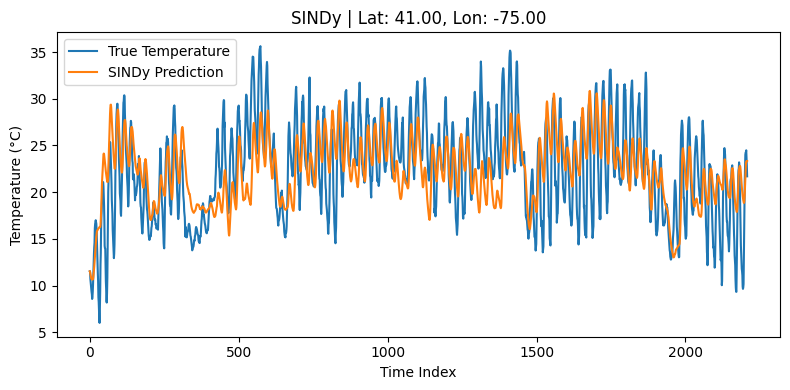

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# pick one grid
row = df.iloc[0]
latitude, longitude = row['latitude'], row['longitude']

df_g = df[(df['latitude']==latitude) & (df['longitude']==longitude)].sort_values('valid_time')

# data
T = df_g['temp_C'].values
R = df_g['ssrd'].values
W = df_g['wind_speed'].values
times = df_g['valid_time'].values

# scaling (same as your baseline)
scaler_X = StandardScaler()
scaler_U = StandardScaler()

T_scaled = scaler_X.fit_transform(T.reshape(-1,1)).flatten()
U_scaled = scaler_U.fit_transform(np.column_stack([R, W]))

R_scaled = U_scaled[:,0]
W_scaled = U_scaled[:,1]

# coefficients (your SINDy result)
a1 = -0.049633
a2 = 0.090488
a3 = -0.027677

# simulate in scaled space
T_pred_scaled = np.zeros_like(T_scaled)
T_pred_scaled[0] = T_scaled[0]

dt = 1

for t in range(len(T_scaled)-1):
    dTdt = a1*T_pred_scaled[t] + a2*R_scaled[t] + a3*W_scaled[t]
    T_pred_scaled[t+1] = T_pred_scaled[t] + dt*dTdt

# back to real units
T_pred = scaler_X.inverse_transform(T_pred_scaled.reshape(-1,1)).flatten()

# evaluation
rmse = np.sqrt(mean_squared_error(T, T_pred))
corr = np.corrcoef(T, T_pred)[0,1]

print("RMSE:", rmse)
print("Correlation:", corr)

# -------------------------------
# ✅ SAVE RESULTS (SINDy format)
# -------------------------------

sindy_df = pd.DataFrame({
    "time": times,
    "latitude": latitude,
    "longitude": longitude,
    "true_T": T,
    "pred_T": T_pred
})

# save CSV
sindy_df.to_csv("sindy_baseline_single_grid.csv", index=False)

print("Saved: sindy_baseline_single_grid.csv")

# -------------------------------
# plot
# -------------------------------
plt.figure(figsize=(8,4))
plt.plot(T, label='True Temperature')
plt.plot(T_pred, label='SINDy Prediction')

plt.title(f"SINDy | Lat: {latitude:.2f}, Lon: {longitude:.2f}")
plt.xlabel("Time Index")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.tight_layout()
plt.show()

## Multi-grid Forward Simulation visualization

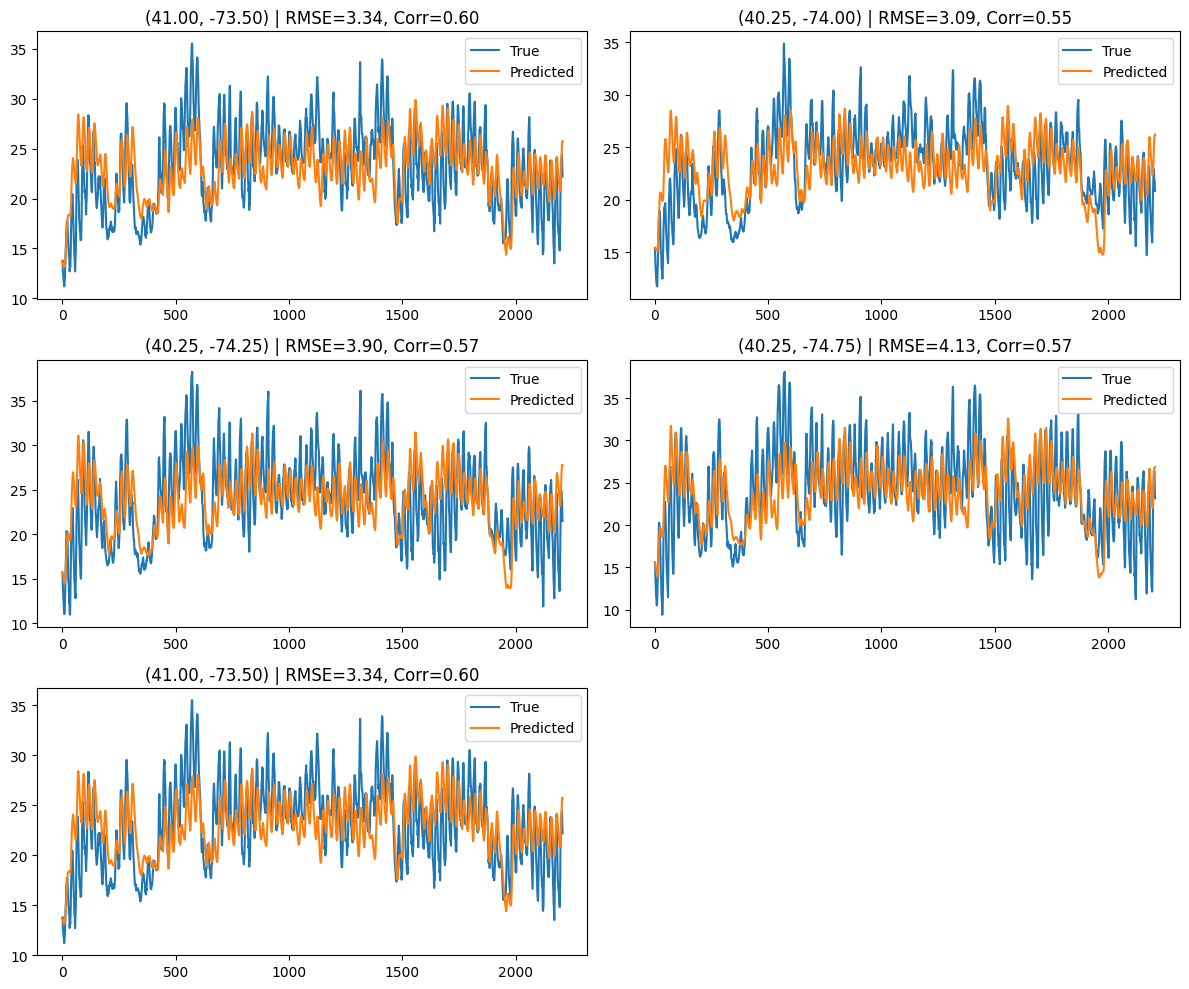

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# pick 5 grids (evenly spaced)
sample_indices = np.linspace(0, len(df)-1, 5, dtype=int)
#sample_grids = df.iloc[sample_indices]
sample_grids = df.sample(n=5, random_state=42)

plt.figure(figsize=(12, 10))

for i, (_, row) in enumerate(sample_grids.iterrows()):
    latitude, longitude = row['latitude'], row['longitude']

    df_g = df[(df['latitude']==latitude) & (df['longitude']==longitude)].sort_values('valid_time')

    T = df_g['temp_C'].values
    R = df_g['ssrd'].values
    W = df_g['wind_speed'].values

    # scaling
    scaler_X = StandardScaler()
    scaler_U = StandardScaler()

    T_scaled = scaler_X.fit_transform(T.reshape(-1,1)).flatten()
    U_scaled = scaler_U.fit_transform(np.column_stack([R, W]))

    R_scaled = U_scaled[:,0]
    W_scaled = U_scaled[:,1]

    # coefficients
    a1 = -0.049633
    a2 = 0.090488
    a3 = -0.027677

    # simulate
    T_pred_scaled = np.zeros_like(T_scaled)
    T_pred_scaled[0] = T_scaled[0]

    dt = 1
    for t in range(len(T_scaled)-1):
        dTdt = a1*T_pred_scaled[t] + a2*R_scaled[t] + a3*W_scaled[t]
        T_pred_scaled[t+1] = T_pred_scaled[t] + dt*dTdt

    # back to physical
    T_pred = scaler_X.inverse_transform(T_pred_scaled.reshape(-1,1)).flatten()

    # metrics
    rmse = np.sqrt(mean_squared_error(T, T_pred))
    corr = np.corrcoef(T, T_pred)[0,1]

    # plot
    plt.subplot(3, 2, i+1)
    plt.plot(T, label='True')
    plt.plot(T_pred, label='Predicted')
    plt.title(f"({latitude:.2f}, {longitude:.2f}) | RMSE={rmse:.2f}, Corr={corr:.2f}")
    plt.legend()

plt.tight_layout()
plt.show()

Version aligned to LSTM evaluation window

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

df["valid_time"] = pd.to_datetime(df["valid_time"])

a1 = -0.049633
a2 = 0.090488
a3 = -0.027677

dt = 1
SEQ_LEN = 7   # use the same value as your LSTM

all_sindy_records = []
grid_metrics = []

for (latitude, longitude), df_g in df.groupby(["latitude", "longitude"]):

    df_g = df_g.sort_values("valid_time").reset_index(drop=True)

    T = df_g["temp_C"].values
    R = df_g["ssrd"].values
    W = df_g["wind_speed"].values
    times = df_g["valid_time"].values

    if len(T) <= SEQ_LEN:
        continue

    scaler_X = StandardScaler()
    scaler_U = StandardScaler()

    T_scaled = scaler_X.fit_transform(T.reshape(-1, 1)).flatten()
    U_scaled = scaler_U.fit_transform(np.column_stack([R, W]))

    R_scaled = U_scaled[:, 0]
    W_scaled = U_scaled[:, 1]

    # start from the same effective forecast start as LSTM
    T_pred_scaled = np.zeros_like(T_scaled)
    T_pred_scaled[:SEQ_LEN] = T_scaled[:SEQ_LEN]

    for t in range(SEQ_LEN - 1, len(T_scaled) - 1):
        dTdt = a1 * T_pred_scaled[t] + a2 * R_scaled[t] + a3 * W_scaled[t]
        T_pred_scaled[t + 1] = T_pred_scaled[t] + dt * dTdt

    T_pred = scaler_X.inverse_transform(T_pred_scaled.reshape(-1, 1)).flatten()

    grid_df = pd.DataFrame({
        "time": times[SEQ_LEN:],
        "latitude": latitude,
        "longitude": longitude,
        "true_T": T[SEQ_LEN:],
        "pred_T": T_pred[SEQ_LEN:]
    })

    all_sindy_records.append(grid_df)

    rmse = np.sqrt(mean_squared_error(T[SEQ_LEN:], T_pred[SEQ_LEN:]))
    corr = np.corrcoef(T[SEQ_LEN:], T_pred[SEQ_LEN:])[0, 1] if len(T[SEQ_LEN:]) > 1 else np.nan

    grid_metrics.append({
        "latitude": latitude,
        "longitude": longitude,
        "rmse": rmse,
        "correlation": corr
    })

sindy_multi_df = pd.concat(all_sindy_records, ignore_index=True)
sindy_metrics_df = pd.DataFrame(grid_metrics)

sindy_multi_df.to_csv("sindy_multi_grid_predictions_aligned.csv", index=False)
sindy_metrics_df.to_csv("sindy_multi_grid_metrics_aligned.csv", index=False)

print("Saved: sindy_multi_grid_predictions_aligned.csv")
print("Saved: sindy_multi_grid_metrics_aligned.csv")

overall_rmse = np.sqrt(mean_squared_error(sindy_multi_df["true_T"], sindy_multi_df["pred_T"]))
print("Overall RMSE across all grids:", overall_rmse)
print("Mean per-grid RMSE:", sindy_metrics_df["rmse"].mean())
print("Mean per-grid correlation:", sindy_metrics_df["correlation"].mean())

Saved: sindy_multi_grid_predictions_aligned.csv
Saved: sindy_multi_grid_metrics_aligned.csv
Overall RMSE across all grids: 3.5142553831483467
Mean per-grid RMSE: 3.459275273029753
Mean per-grid correlation: 0.5297237435185561


## September out-of-sample validation (extrapolation)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# load coefficients
#results_df = pd.read_csv('results_df.csv')

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving era5_sep2025_multigrid.csv to era5_sep2025_multigrid.csv


In [ ]:
# load September data
df_sep = pd.read_csv('era5_sep2025_multigrid.csv')
df_sep['valid_time'] = pd.to_datetime(df_sep['valid_time'])

Loop over grids (out-of-sample simulation)

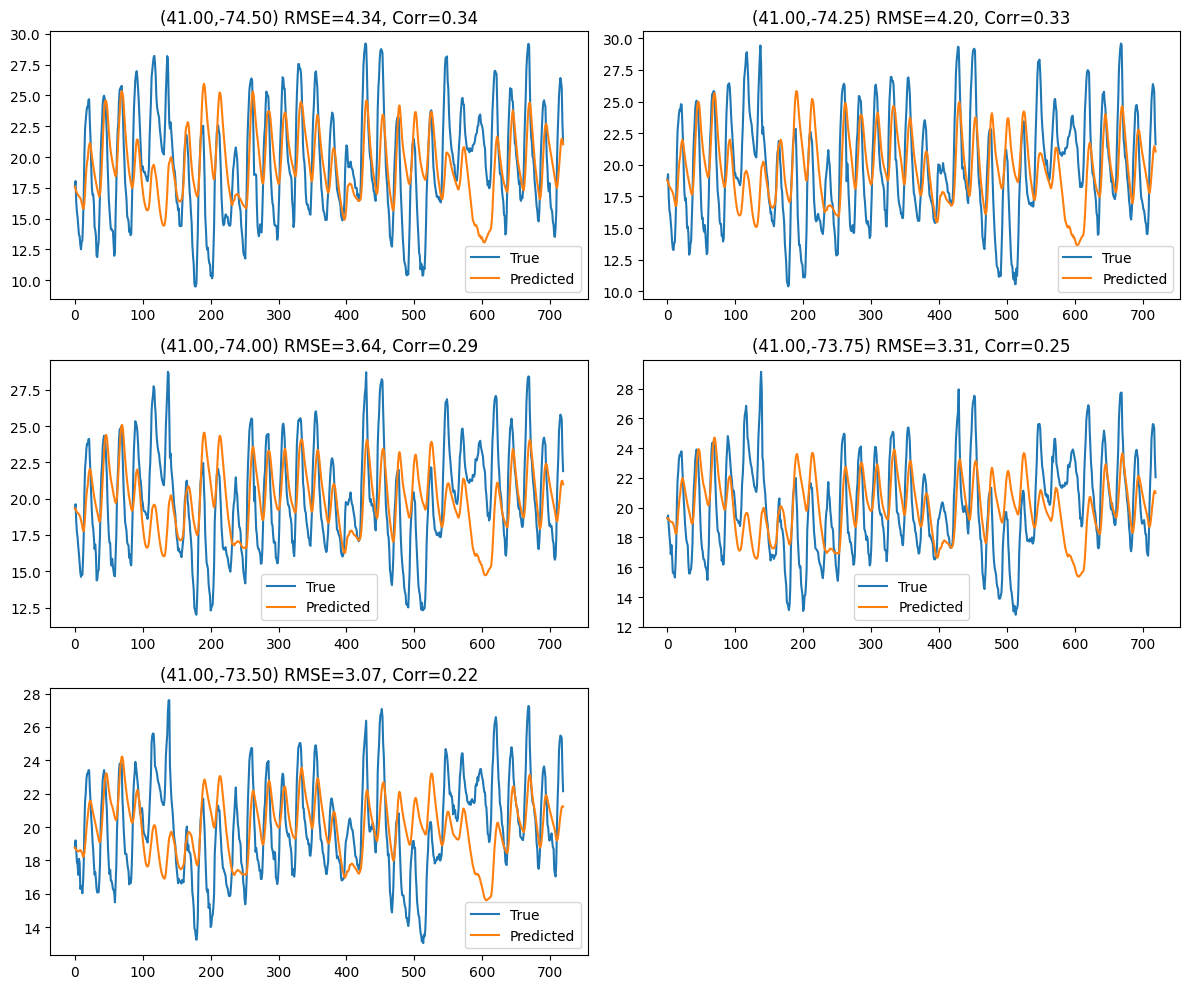

In [ ]:
rmse_list = []
corr_list = []

plots_done = 0
plt.figure(figsize=(12,10))

for _, row in results_df.iterrows():

    lat, lon = row['lat'], row['lon']

    df_g = df_sep[(df_sep['latitude']==lat) & (df_sep['longitude']==lon)]
    df_g = df_g.sort_values('valid_time')

    if len(df_g) < 50:
        continue

    # variables
    T = df_g['temp_C'].values
    R = df_g['ssrd'].values
    W = df_g['wind_speed'].values

    # scaling (re-fit on September — important)
    scaler_X = StandardScaler()
    scaler_U = StandardScaler()

    T_scaled = scaler_X.fit_transform(T.reshape(-1,1)).flatten()
    U_scaled = scaler_U.fit_transform(np.column_stack([R, W]))

    R_scaled = U_scaled[:,0]
    W_scaled = U_scaled[:,1]

    # coefficients from TRAINING
    a1 = row['T_coef']
    a2 = row['R_coef']
    a3 = row['W_coef']

    # forward simulation
    T_pred_scaled = np.zeros_like(T_scaled)
    T_pred_scaled[0] = T_scaled[0]

    dt = 1

    for t in range(len(T_scaled)-1):
        dTdt = a1*T_pred_scaled[t] + a2*R_scaled[t] + a3*W_scaled[t]
        T_pred_scaled[t+1] = T_pred_scaled[t] + dt*dTdt

    # back to real units
    T_pred = scaler_X.inverse_transform(T_pred_scaled.reshape(-1,1)).flatten()

    # metrics
    rmse = np.sqrt(mean_squared_error(T, T_pred))
    corr = np.corrcoef(T, T_pred)[0,1]

    rmse_list.append(rmse)
    corr_list.append(corr)

    # plot only 5 grids for visualization
    if plots_done < 5:
        plt.subplot(3,2,plots_done+1)
        plt.plot(T, label='True')
        plt.plot(T_pred, label='Predicted')
        plt.title(f"({lat:.2f},{lon:.2f}) RMSE={rmse:.2f}, Corr={corr:.2f}")
        plt.legend()
        plots_done += 1

plt.tight_layout()
plt.show()

Summary statistics

In [ ]:
print("Out-of-sample performance (September):\n")

print("Mean RMSE:", np.mean(rmse_list))
print("Std RMSE:", np.std(rmse_list))

print("Mean Correlation:", np.mean(corr_list))
print("Std Correlation:", np.std(corr_list))

Out-of-sample performance (September):

Mean RMSE: 2.8213795659756293
Std RMSE: 0.9433156037388967
Mean Correlation: 0.22400340173727645
Std Correlation: 0.1132047534629849


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# -----------------------------
# 1) Fit scalers on TRAINING data
# -----------------------------
train_df = pd.read_csv("era5_nyc_summer_accum.csv")
train_df["valid_time"] = pd.to_datetime(train_df["valid_time"])

# per-grid scaling (MATCH TRAINING)
scaler_X = StandardScaler()
scaler_U = StandardScaler()

T_scaled = scaler_X.fit_transform(T.reshape(-1,1)).flatten()
U_scaled = scaler_U.fit_transform(np.column_stack([R, W]))

# -----------------------------
# 2) September extrapolation
# -----------------------------
df_sep["valid_time"] = pd.to_datetime(df_sep["valid_time"])

SEQ_LEN = 7
dt = 1

sindy_sep_records = []
sindy_sep_metrics = []

for _, row in results_df.iterrows():

    lat, lon = row["lat"], row["lon"]

    df_g = df_sep[
        (df_sep["latitude"] == lat) & (df_sep["longitude"] == lon)
    ].sort_values("valid_time").reset_index(drop=True)

    if len(df_g) <= SEQ_LEN:
        continue

    # variables
    T = df_g["temp_C"].values
    R = df_g["ssrd"].values
    W = df_g["wind_speed"].values
    times = df_g["valid_time"].values

    # -----------------------------
    # IMPORTANT: use transform only
    # -----------------------------
    T_scaled = scaler_X.transform(T.reshape(-1, 1)).flatten()
    U_scaled = scaler_U.transform(np.column_stack([R, W]))

    R_scaled = U_scaled[:, 0]
    W_scaled = U_scaled[:, 1]

    # coefficients from training
    a1 = row["T_coef"]
    a2 = row["R_coef"]
    a3 = row["W_coef"]

    # align forecast start with LSTM
    T_pred_scaled = np.zeros_like(T_scaled)
    T_pred_scaled[:SEQ_LEN] = T_scaled[:SEQ_LEN]

    for t in range(SEQ_LEN - 1, len(T_scaled) - 1):
        dTdt = a1 * T_pred_scaled[t] + a2 * R_scaled[t] + a3 * W_scaled[t]
        T_pred_scaled[t + 1] = T_pred_scaled[t] + dt * dTdt

    # back to physical units using TRAINING scaler
    T_pred = scaler_X.inverse_transform(T_pred_scaled.reshape(-1, 1)).flatten()

    # save aligned prediction window
    grid_df = pd.DataFrame({
        "time": times[SEQ_LEN:],
        "latitude": lat,
        "longitude": lon,
        "true_T": T[SEQ_LEN:],
        "pred_T": T_pred[SEQ_LEN:]
    })

    sindy_sep_records.append(grid_df)

    rmse = np.sqrt(mean_squared_error(T[SEQ_LEN:], T_pred[SEQ_LEN:]))
    corr = np.corrcoef(T[SEQ_LEN:], T_pred[SEQ_LEN:])[0, 1] if len(T[SEQ_LEN:]) > 1 else np.nan

    sindy_sep_metrics.append({
        "latitude": lat,
        "longitude": lon,
        "rmse": rmse,
        "correlation": corr
    })

sindy_sep_df = pd.concat(sindy_sep_records, ignore_index=True)
sindy_sep_metrics_df = pd.DataFrame(sindy_sep_metrics)

sindy_sep_df.to_csv("sindy_september_extrapolation_fixed_scaling.csv", index=False)
sindy_sep_metrics_df.to_csv("sindy_september_extrapolation_metrics_fixed_scaling.csv", index=False)

print("Saved: sindy_september_extrapolation_fixed_scaling.csv")
print("Saved: sindy_september_extrapolation_metrics_fixed_scaling.csv")
print("Unique grids saved:", sindy_sep_df[["latitude", "longitude"]].drop_duplicates().shape[0])
print("Total rows saved:", len(sindy_sep_df))

overall_rmse = np.sqrt(mean_squared_error(sindy_sep_df["true_T"], sindy_sep_df["pred_T"]))
print("Overall RMSE across all September grids:", overall_rmse)
print("Mean per-grid RMSE:", sindy_sep_metrics_df["rmse"].mean())
print("Mean per-grid correlation:", sindy_sep_metrics_df["correlation"].mean())

Saved: sindy_september_extrapolation_fixed_scaling.csv
Saved: sindy_september_extrapolation_metrics_fixed_scaling.csv
Unique grids saved: 21
Total rows saved: 14973
Overall RMSE across all September grids: 2.911576280727563
Mean per-grid RMSE: 2.7516713459884863
Mean per-grid correlation: 0.24775928640783237


In [ ]:
print("results_df rows:", len(results_df))

print("Unique coefficient grids in results_df:",
      results_df[["lat", "lon"]].drop_duplicates().shape[0])

print(results_df[["lat", "lon"]].drop_duplicates().sort_values(["lat", "lon"]))

results_df rows: 45
Unique coefficient grids in results_df: 45
      lat    lon
36  40.00 -75.00
37  40.00 -74.75
38  40.00 -74.50
39  40.00 -74.25
40  40.00 -74.00
41  40.00 -73.75
42  40.00 -73.50
43  40.00 -73.25
44  40.00 -73.00
27  40.25 -75.00
28  40.25 -74.75
29  40.25 -74.50
30  40.25 -74.25
31  40.25 -74.00
32  40.25 -73.75
33  40.25 -73.50
34  40.25 -73.25
35  40.25 -73.00
18  40.50 -75.00
19  40.50 -74.75
20  40.50 -74.50
21  40.50 -74.25
22  40.50 -74.00
23  40.50 -73.75
24  40.50 -73.50
25  40.50 -73.25
26  40.50 -73.00
9   40.75 -75.00
10  40.75 -74.75
11  40.75 -74.50
12  40.75 -74.25
13  40.75 -74.00
14  40.75 -73.75
15  40.75 -73.50
16  40.75 -73.25
17  40.75 -73.00
0   41.00 -75.00
1   41.00 -74.75
2   41.00 -74.50
3   41.00 -74.25
4   41.00 -74.00
5   41.00 -73.75
6   41.00 -73.50
7   41.00 -73.25
8   41.00 -73.00
